<a href="https://colab.research.google.com/github/Sanjana-Kannoorkar/K-Nearest-Neighbors-Classification/blob/main/task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [7]:
#Load the dataset
df = pd.read_csv('Iris.csv')
print(df.head())

#Check basic info
print("\nDataset Information: ")
print(df.info())

#Check Class Distribution
print("\nClass Distribution: ")
print(df['Species'].value_counts())

#Drop Id column as it is not needed
df = df.drop('Id', axis = 1)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ 

In [19]:
#Separate Features and Target
X = df.drop('Species', axis=1)
y = df['Species']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(X_scaled, columns = X.columns).head())
print("\nTarget labels: \n", y.unique())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       0.222222      0.625000       0.067797      0.041667
1       0.166667      0.416667       0.067797      0.041667
2       0.111111      0.500000       0.050847      0.041667
3       0.083333      0.458333       0.084746      0.041667
4       0.194444      0.666667       0.067797      0.041667

Target labels: 
 [0 1 2]


In [20]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize the model with k=3
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

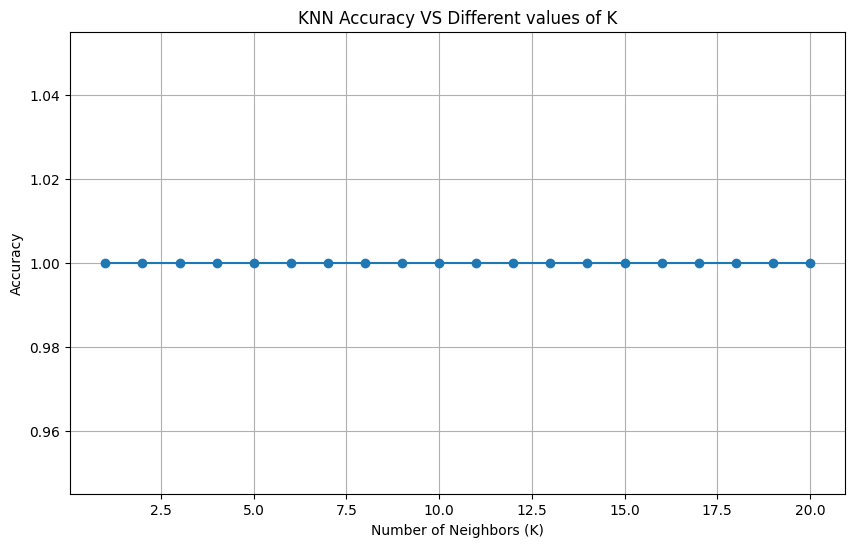

In [24]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train, y_train)
  y_pred_k = knn.predict(X_test)
  acc = accuracy_score(y_test, y_pred_k)
  accuracies.append(acc)

#Plotting accuracy VS K
plt.figure(figsize = (10, 6))
plt.plot(k_values, accuracies, marker = 'o')
plt.title("KNN Accuracy VS Different values of K")
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [25]:
y_pred = knn.predict(X_test)
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

#Confusion Matrix
conf_matrix = confusion_matrix (y_test, y_pred)
print("\nCOnfusion Matrix: \n", conf_matrix)

#Classification Report
report = classification_report(y_test, y_pred)
print("\nClassificiaction Report:\n", report)

Accuracy:  1.0

COnfusion Matrix: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classificiaction Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



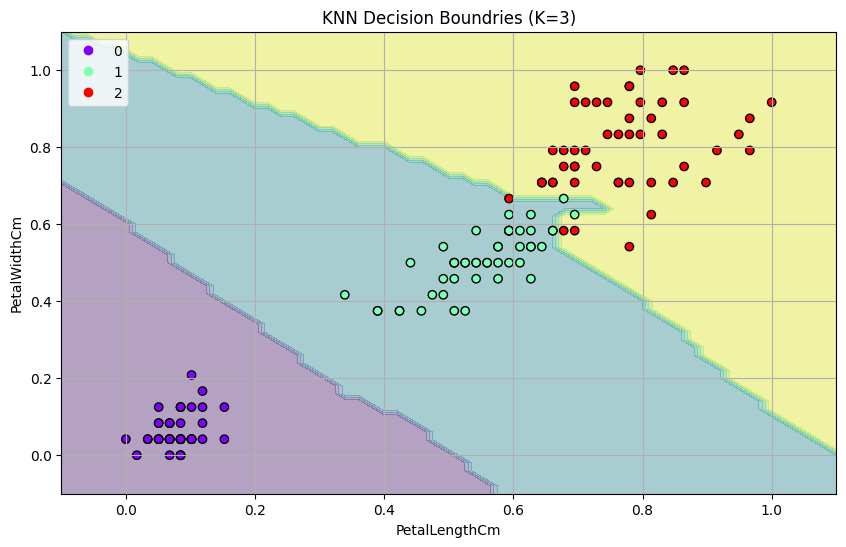

In [31]:
feature1 = 'PetalLengthCm'
feature2 = 'PetalWidthCm'

#Extract selected features and scale them
X_vis = df[[feature1, feature2]]
X_vis_scaled = scaler.fit_transform(X_vis)
y_vis = df['Species']

#Train KNN on selected 2D features
knn_vis = KNeighborsClassifier(n_neighbors = 3)
knn_vis.fit(X_vis_scaled, y_vis)

#Create a meshgrid
h = 0.02
x_min, x_max = X_vis_scaled[:, 0].min() - 0.1, X_vis_scaled[:, 0].max() + 0.1
y_min, y_max = X_vis_scaled[:, 1].min() - 0.1, X_vis_scaled[:, 0].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

#Predit over the grid
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#Plotting
plt.figure(figsize = (10, 6))
plt.contourf(xx, yy, Z, alpha = 0.4)
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c = pd.factorize(y_vis)[0], edgecolor = 'k', cmap = plt.cm.rainbow)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("KNN Decision Boundries (K=3)")
# Get handles and labels from scatter.legend_elements()
handles, labels = scatter.legend_elements()
# Pass handles and labels to plt.legend()
plt.legend(handles=handles, labels=labels)
plt.grid(True)
plt.show()